In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
# from torchsummary import summary
import torchaudio.transforms as T
import torchaudio
import pickle
import matplotlib.pyplot as plt
import librosa

from tqdm.auto import tqdm, trange
import os
import sys
from pathlib import Path
from datetime import datetime
import random
from random import randint

import gc
import opensmile

import time

/Users/i.litvinov/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data gaining

In [2]:
ROOT = "./data_2/data_2/"
ALL_SOUNDS = list(Path(ROOT).glob("**/*.wav"))
ALL_SOUNDS = list(filter(lambda x: not x.name.startswith("."), ALL_SOUNDS))
print("Number of sounds:", len(ALL_SOUNDS))

Number of sounds: 97377


In [3]:
data_list = []
with open('data_base_2.pickle', 'rb') as fh:
  data_list = pickle.load(fh)

In [4]:
len(data_list)

97377

In [5]:
random.seed(123456)
np.random.seed(123456)
torch.manual_seed(123456)

**For graphs**

In [6]:
def sound_show(inp, title=None, marks_true=None, marks_pred=None, sample_rate=16000):
    time = np.linspace(0., inp.size / sample_rate, inp.size)
    height = 1.5 * np.max(np.abs(inp))
    plt.figure(figsize=(16, 6))
    signal_line, = plt.plot(time, inp, label='Signal')
    plt.title(title)

    handles = [signal_line]
    labels = ['Signal']

    ax = plt.gca()

    if marks_pred is not None:
        marks_pred = torch.squeeze(marks_pred.detach()).cpu().numpy()
        words_grid_pred = find_words_edges(marks_pred, sample_rate)
        for edges in words_grid_pred:
            span = ax.axvspan(edges[0], edges[1], color='green', alpha=0.2)
        handles.append(span)
        labels.append('Predicted speech')

    if marks_true is not None:
        marks_true = torch.squeeze(marks_true).cpu().numpy()
        words_grid_true = find_words_edges(marks_true, sample_rate)
        for edges in words_grid_true:
            span = ax.axvspan(edges[0], edges[1], color='red', alpha=0.3, linestyle='--')
        handles.append(span)
        labels.append('True speech')

    plt.legend(handles, labels)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def find_words_edges(marks, sample_rate=16000):
    lst = []
    in_speech = False
    temp = []
    for i, m in enumerate(marks):
        if m == 1 and not in_speech:
            temp = [i / sample_rate]
            in_speech = True
        elif m == 0 and in_speech:
            temp.append(i / sample_rate)
            lst.append(temp)
            in_speech = False
    if in_speech:
        temp.append(len(marks) / sample_rate)
        lst.append(temp)
    return np.array(lst)


**Splitting subset**

In [7]:
import numpy as np


for i in range(len(data_list)):
    data_list[i]['marks'] = np.repeat(data_list[i]['marks'], 2)

In [8]:
path_data = './data_2/data_2'

end_idx_tv = 87000
train_valid_subset = data_list[:end_idx_tv]
test_subset = data_list[end_idx_tv:]

lengths = [int(len(train_valid_subset) * 0.9), int(len(train_valid_subset) * 0.1)]
train_subset, valid_subset = torch.utils.data.random_split(train_valid_subset, lengths)
print(train_subset[0])

{'name': '7a263d8418b34994ad76a38298347100_SNR_3', 'marks': array([0, 0, 0, ..., 0, 0, 0], dtype=int8)}


In [9]:
del data_list

In [10]:
mask_snr_1 = np.array([data['name'].split('SNR_')[1] for data in test_subset]) == '1'
mask_snr_3 = np.array([data['name'].split('SNR_')[1] for data in test_subset]) == '3'

In [11]:
test_subset_snr_1 = np.array(test_subset)[mask_snr_1]
test_subset_snr_3 = np.array(test_subset)[mask_snr_3]

In [12]:
len(test_subset_snr_1), len(test_subset_snr_3)

(5205, 5172)

In [13]:
gc.collect()

0

# Data preporation

**Emobase**

In [14]:
class SoundDataset_emobase(torch.utils.data.Dataset):
    def __init__(self, rootdir, subset, transform=None):
        self.transform = transform
        self.rootdir = rootdir
        self.subset = subset
        self.n_subset = len(self.subset)
        self.smile = opensmile.Smile(
                        feature_set=opensmile.FeatureSet.emobase,
                        feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
                        )
    def __getitem__(self, index):
        xname, y = self.subset[index].values()
        signal, sr = librosa.load(f"{self.rootdir}/{xname}.wav", sr=16000)
        X = torch.unsqueeze(torch.transpose(self.transform(self.smile.process_signal(signal, 16000).to_numpy().astype('float32')), 0, 1), 0)
        y = torch.unsqueeze(self.transform(y.astype('float32')), 0)
#         signal = torch.unsqueeze(self.transform(signal.astype('float32')), 0)


        return xname, X, y, signal

    def __len__(self):
        return len(self.subset)

    def preprocessing(self):
        for i in tqdm(np.arange(self.n_subset)):
            if self.transform:
                xname, _ = self.subset[i].values()
                data_features = torch.unsqueeze(torch.transpose(self.transform(self.smile.process_file(f"{self.rootdir}/{xname}.wav").to_numpy().astype('float32')), 0, 1), 0)
                self.data.append(data_features)

class ToTensor(object):
    def __call__(self, sample):
        return torch.from_numpy(sample)

**Emobase dataset**

tensor([[[1.5305e-07, 1.7089e-07, 1.6558e-07,  ..., 1.1356e-07,
          8.3668e-08, 8.3175e-08],
         [5.6873e-01, 5.8750e-01, 5.8095e-01,  ..., 4.9804e-01,
          4.6392e-01, 4.6321e-01],
         [9.4710e+00, 8.9950e+00, 1.0900e+01,  ..., 5.7140e+00,
          3.5933e+00, 2.0833e+00],
         ...,
         [1.7962e-01, 1.7313e-01, 1.7193e-01,  ..., 1.5694e-01,
          1.6337e-01, 1.6880e-01],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.2508e+02,
          1.2508e+02, 1.2508e+02]]]) tensor([[0., 0., 0.,  ..., 0., 0., 0.]]) [-0.00829035 -0.01765829 -0.01704188 ...  0.02403177  0.02077562
  0.00543169]


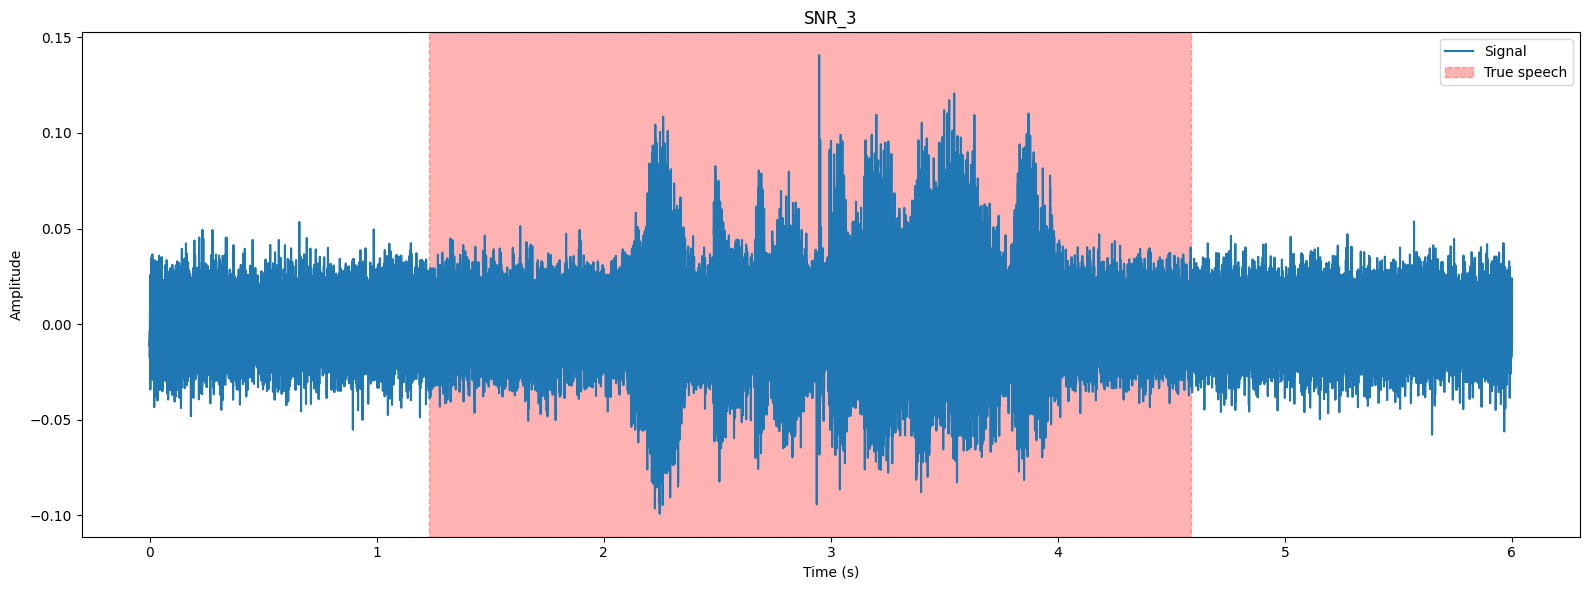

torch.Size([26, 598])


In [15]:
transform_emobase = transforms.Compose([ToTensor()])
data_set_emobase = {
            'train': SoundDataset_emobase(rootdir=path_data, subset=train_subset, transform=transform_emobase),
            'valid': SoundDataset_emobase(rootdir=path_data, subset=valid_subset, transform=transform_emobase),
            'test_snr_1': SoundDataset_emobase(rootdir=path_data, subset=test_subset_snr_1, transform=transform_emobase),
            'test_snr_3': SoundDataset_emobase(rootdir=path_data, subset=test_subset_snr_3, transform=transform_emobase),
            'test': SoundDataset_emobase(rootdir=path_data, subset=test_subset, transform=transform_emobase)
           }

batch_size = 512
loaders_emobase = {
            'train': torch.utils.data.DataLoader(data_set_emobase['train'], batch_size=batch_size, shuffle=True),
            'valid': torch.utils.data.DataLoader(data_set_emobase['valid'], batch_size=batch_size, shuffle=True),
            'test_snr_1': torch.utils.data.DataLoader(data_set_emobase['test_snr_1'], batch_size=1, shuffle=False),
            'test_snr_3': torch.utils.data.DataLoader(data_set_emobase['test_snr_3'], batch_size=1, shuffle=False),
            'test': torch.utils.data.DataLoader(data_set_emobase['test'], batch_size=1, shuffle=False)
          }

dataset_sizes = {x: len(data_set_emobase[x]) for x in ['train', 'valid', 'test_snr_1', 'test_snr_3']}
xname, X, y, signal = data_set_emobase['train'][8]
print(X, y, signal)
sound_show(signal, title=f'SNR_{xname.split("_SNR_")[1]}', marks_true=y, marks_pred=None)
print(X[0].size())

In [16]:
# 801, 80

In [17]:
data_set_emobase

{'train': <__main__.SoundDataset_emobase at 0x16e55a490>,
 'valid': <__main__.SoundDataset_emobase at 0x16e55a2e0>,
 'test_snr_1': <__main__.SoundDataset_emobase at 0x104182520>,
 'test_snr_3': <__main__.SoundDataset_emobase at 0x15f6146d0>,
 'test': <__main__.SoundDataset_emobase at 0x1041786a0>}

In [ ]:
import torch
import os

output_dir = 'train_samples'
os.makedirs(output_dir, exist_ok=True)

for idx in tqdm(range(len(data_set_emobase['train']))):
    xname, X, y, signal = data_set_emobase['train'][idx]
    # Сохраним отдельный сэмпл, ключ можно включить в имя файла
    torch.save({'xname': xname, 'X': X, 'y': y, 'signal': signal},
               os.path.join(output_dir, f'sample_{idx}.pt'))


  2%|▏         | 1689/78300 [01:01<48:20, 26.42it/s]

In [ ]:
output_dir = 'valid_samples'
os.makedirs(output_dir, exist_ok=True)

for idx in tqdm(range(len(data_set_emobase['valid']))):
    xname, X, y, signal = data_set_emobase['valid'][idx]
    # Сохраним отдельный сэмпл, ключ можно включить в имя файла
    torch.save({'xname': xname, 'X': X, 'y': y, 'signal': signal},
               os.path.join(output_dir, f'sample_{idx}.pt'))


In [ ]:
output_dir = 'test_samples'
os.makedirs(output_dir, exist_ok=True)

for idx in tqdm(range(len(data_set_emobase['test']))):
    xname, X, y, signal = data_set_emobase['test'][idx]
    # Сохраним отдельный сэмпл, ключ можно включить в имя файла
    torch.save({'xname': xname, 'X': X, 'y': y, 'signal': signal},
               os.path.join(output_dir, f'sample_{idx}.pt'))


# Models

**New model with emobase based on the Article**

In [ ]:
class Conv_emobase(nn.Module):
    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(p=0.7)
        self.activation = nn.LeakyReLU(negative_slope=0.2)

        # convolution
        self.conv1 = nn.Conv2d(in_channels=1,
                      out_channels=64,
                      kernel_size=(5, 20),
                      stride=(2, 6),
                      padding=(2, 10))
        self.conv1_batch_norm = nn.BatchNorm2d(num_features=64)

        self.conv2 = nn.Conv2d(in_channels=64,
                      out_channels=128,
                      kernel_size=(3, 3),
                      stride=(2, 2),
                      padding=(1, 1))
        self.conv2_batch_norm = nn.BatchNorm2d(num_features=128)

        self.conv3 = nn.Conv2d(in_channels=128,
                      out_channels=256,
                      kernel_size=(6, 13),
                      stride=(2, 2),
                      padding=(0, 1))
        self.conv3_batch_norm = nn.BatchNorm2d(num_features=256)

        # deconvolution
        self.deconv1 = nn.ConvTranspose1d(in_channels=256,
                               out_channels=128,
                               kernel_size=101,
                               stride=10,
                               padding=50,
                               output_padding=9)
        self.deconv1_batch_norm = nn.BatchNorm1d(num_features=128)

        self.deconv2 = nn.ConvTranspose1d(in_channels=128,
                               out_channels=64,
                               kernel_size=101,
                               stride=12,
                               padding=50,
                               output_padding=11)
        self.deconv2_batch_norm = nn.BatchNorm1d(num_features=64)

        self.deconv3 = nn.ConvTranspose1d(
            in_channels=64,
            out_channels=1,
            kernel_size=101,
            stride=40,               # было 20
            padding=50,
            output_padding=39        # было 19
        )

    def forward(self, x):
        # Convolution
        x = self.conv1_batch_norm(self.activation(self.dropout(self.conv1(x))))
        x = self.conv2_batch_norm(self.activation(self.dropout(self.conv2(x))))
        x = self.conv3_batch_norm(self.activation(self.dropout(self.conv3(x))))

        # Deconvolution
        x = torch.squeeze(x, -2)
        x = self.deconv1_batch_norm(self.activation(self.dropout(self.deconv1(x))))
        x = self.deconv2_batch_norm(self.activation(self.dropout(self.deconv2(x))))

        return self.deconv3(x)

# Model prepare

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

In [ ]:
def init_weights(m):
    if type(m) in (nn.Conv1d, nn.Conv2d, nn.ConvTranspose1d):
        nn.init.kaiming_uniform_(m.weight, a=0.2, nonlinearity='leaky_relu')
    else:
        print('Not setting weights for type {}'.format(type(m)))
        

In [ ]:
def save(path, loss, epoch, model, optim, scheduler, train_losses, valid_losses, train_metrics, valid_metrics):
    torch.save({
        'loss': loss,
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optim.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss_epochs': train_losses,
        'valid_loss_epochs': valid_losses,
        'train_metrics': train_metrics,
        'valid_metrics': valid_metrics
    }, path)

In [ ]:
def binary_acc(y_pred, y_test):
    correct_results_sum = (y_pred == y_test).sum().float()
    print(torch.unique(y_pred))
    acc = correct_results_sum/(y_test.shape[0]*y_test.shape[2])
    # acc = torch.round(acc * 100)
    
    return acc

In [ ]:
epochs = 13

In [ ]:
def train(model, optim, loss, scheduler, dataloader):
    total = 0
    correct = 0
    losses = []

    model.train()
    for i, batch in enumerate(tqdm(dataloader)):
        xname, X, marks, _ = batch
        X, marks = X.cuda(), marks.cuda()
        optim.zero_grad()
        out = model(X)
        loss_batch = loss(out, marks)
        losses.append(loss_batch.item())
        loss_batch.backward()
        optim.step()
        scheduler.step()

        prediction = torch.round(torch.sigmoid(out)).type(torch.int8)
        marks = marks.type(torch.int8)

    return np.mean(losses), {'Accuracy': binary_acc(prediction, marks)}

In [ ]:
def valid(model, loss, dataloader):
    total = 0
    correct = 0
    losses = []

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader)):
            xname, X, marks, _ = batch
            X, marks = X.cuda(), marks.cuda()
            out = model(X)
            loss_batch = loss(out, marks)
            losses.append(loss_batch.item())

            prediction = torch.round(torch.sigmoid(out)).type(torch.int8)
            marks = marks.type(torch.int8)

    return np.mean(losses), {'Accuracy': binary_acc(prediction, marks)}

In [ ]:
def init_model(path=None):
    max_lr = 0.05
    div_factor = 250
    weight_decay = 0.0005

    loss = nn.BCEWithLogitsLoss(pos_weight=torch.ones(96000, dtype=torch.float16).cuda() * 3).cuda()

    model = Conv_emobase().cuda()
    optim = torch.optim.AdamW(model.parameters(), lr=max_lr / div_factor,
                                weight_decay=weight_decay, amsgrad=True)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optim, max_lr=max_lr,
                            steps_per_epoch=len(loaders_emobase['train']),
                            epochs=epochs, div_factor=div_factor)

    if path is None:    
        model.apply(init_weights)

    epoch = 0
    train_losses = []
    valid_losses = []
    train_metrics = {
        'Accuracy': []
    }
    valid_metrics = {
        'Accuracy': []
    }

    if path is not None:
        checkpoint = torch.load(path)
        
        # print(checkpoint['optimizer_state_dict'])

        model.load_state_dict(checkpoint['model_state_dict'])
        optim.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        train_losses = checkpoint['train_loss_epochs']
        valid_losses = checkpoint['valid_loss_epochs']
        epoch = checkpoint['epoch'] + 1
        print(epoch, valid_losses)
        loss = checkpoint['loss']
        train_metrics = checkpoint['train_metrics']
        valid_metrics = checkpoint['valid_metrics']
    
    return model, loss, optim, scheduler, epoch, train_losses, valid_losses, train_metrics, valid_metrics


# Model emobase training

In [ ]:
!wandb login --relogin a4fc0db907801a21173615cb84708e1774b986a4
wandb.init(project="emobase_last_kaggle")
wandb.config = {
  "epochs": epochs,
  "batch_size": 512
}

In [ ]:
savedir = '/kaggle/working'
torch.cuda.empty_cache()
gc.collect()

path = '/kaggle/working/emobase_5_0.152_2023-03-16_08'
model, loss, optim, scheduler, epoch, train_losses, valid_losses, train_metrics, valid_metrics = init_model(path=None)
# print(scheduler, epoch, train_losses, valid_losses, train_metrics, valid_metrics)
model_name = 'emobase'
best_path = None
best_acc = 0
bect_epoch = 0

wandb.watch(model)
for i in range(epoch, epochs):
    train_loss, metrics = train(model, optim, loss, scheduler, loaders_emobase['train'])
    
    train_losses.append(train_loss)
    train_acc = metrics['Accuracy'].item()
    train_metrics['Accuracy'].append(train_acc)

    valid_loss, metrics = valid(model, loss, loaders_emobase['valid'])
    valid_acc = metrics['Accuracy'].item()
    valid_metrics['Accuracy'].append(valid_acc)

    print(f'{i} epoch')
    print(valid_loss)
    if i == 0 or valid_loss < np.min(valid_losses) or True:
        best_path = os.path.join(savedir, datetime.now().strftime('{0}_{1}_{2:.3f}_%Y-%m-%d_%H'.format(model_name, i, valid_loss)))
        print(best_path)
        valid_losses.append(valid_loss)
        save(best_path, loss, i, model, optim, scheduler, train_losses, valid_losses, train_metrics, valid_metrics)

    else:
        valid_losses.append(valid_loss)

    wandb.log({"train_loss": train_loss})
    wandb.log({"valid_loss": valid_loss})
    wandb.log({"train_accuracy": train_acc})
    wandb.log({"valid_accuracy": valid_acc})
        # wandb.log({"Learning rate": scheduler.get_last_lr()[0]})
wandb.finish()

# Sanity check

In [ ]:
from sklearn.metrics import classification_report
import sys

In [ ]:
def metrics_test_compute(model, loader):
    torch.cuda.empty_cache()
    gc.collect()

    test_metrics = {
            'acc': np.array([]),
            'prec': np.array([]),
            'rec': np.array([]),
            'F1': np.array([])
    }

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader)):
            xname, X, marks, _ = batch
            X, marks = X.cuda(), marks.cuda()
            out = model(X)

            marks = marks.squeeze().type(torch.int8)
            prediction = torch.round(torch.sigmoid(out)).squeeze().type(torch.int8)

            temp_dict = classification_report(prediction.cpu().numpy(), marks.cpu().numpy(), output_dict=True)['1']
            temp_acc = classification_report(prediction.cpu().numpy(), marks.cpu().numpy(), output_dict=True)['accuracy']
            test_metrics['acc'] = np.append(test_metrics['acc'], temp_acc)
            test_metrics['prec'] = np.append(test_metrics['prec'], temp_dict['precision'])
            test_metrics['rec'] = np.append(test_metrics['rec'], temp_dict['recall'])
            test_metrics['F1'] = np.append(test_metrics['F1'], temp_dict['f1-score'])


    metrics = {'Accuracy': np.mean(test_metrics['acc']), 'Precision': np.mean(test_metrics['prec']), 'Recall': np.mean(test_metrics['rec']), 'F1': np.mean(test_metrics['F1'])}
    return metrics

## Emobase

In [ ]:
model_emobase = Conv_emobase().cuda()
checkpoint = torch.load('/kaggle/working/emobase_9_0.147_2023-03-16_16')
model_emobase.load_state_dict(checkpoint['model_state_dict'])

### SNR 3

In [ ]:
metrics_test_compute(model_emobase, loaders_emobase['test_snr_3'])

### SNR 1

In [ ]:
metrics_test_compute(model_emobase, loaders_emobase['test_snr_1'])

### Common Metrics

In [ ]:
metrics_test_compute(model_emobase, loaders_emobase['test'])

a4fc0db907801a21173615cb84708e1774b986a4

### Example

In [ ]:
num = randint(0, len(data_set_emobase['test_snr_1']))
name, data, marks, signal = data_set_emobase['test_snr_1'][num]
model_emobase.eval()
pred = model_emobase(data.cuda().unsqueeze(0))
pred = torch.round(torch.sigmoid(pred))

sound_show(signal, title=name, marks_true=marks, marks_pred=pred)

In [ ]:
signal